In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pybamm

In [2]:
sns.set_theme(style="whitegrid", palette="muted")

# Extract the actual thickness parameters directly from the PyBaMM model used during generation
# We load Chen2020 because we used its macro-geometry for our Virtual Cell Design
param_virtual = pybamm.ParameterValues("Chen2020")
# Convert meters to micrometers
L_n = param_virtual["Negative electrode thickness [m]"] * 1e6
L_s = param_virtual["Separator thickness [m]"] * 1e6
L_p = param_virtual["Positive electrode thickness [m]"] * 1e6
L_total = L_n + L_s + L_p
# Calculate the precise Y-coordinates where the materials meet
sep_start = L_n
cat_start = L_n + L_s

print(f"Extracted Geometry: Anode={L_n:.1f}um, Separator={L_s:.1f}um, Cathode={L_p:.1f}um. Total={L_total:.1f}um")


dataset = np.load('dataset_sodium.npz')

X = dataset['X']
Y = dataset['Y']
T_durations = dataset['T']

num_samples = X.shape[0]
currents = X[:, 0]
k_anode = X[:, 1]       # All three diffusivity values are dimensionless scale factors (~0.3x-3x), applied to Chayambuka2022's state-of-charge-dependent curves
k_cathode = X[:, 2]
k_electrolyte = X[:, 3]

Extracted Geometry: Anode=85.2um, Separator=12.0um, Cathode=75.6um. Total=172.8um


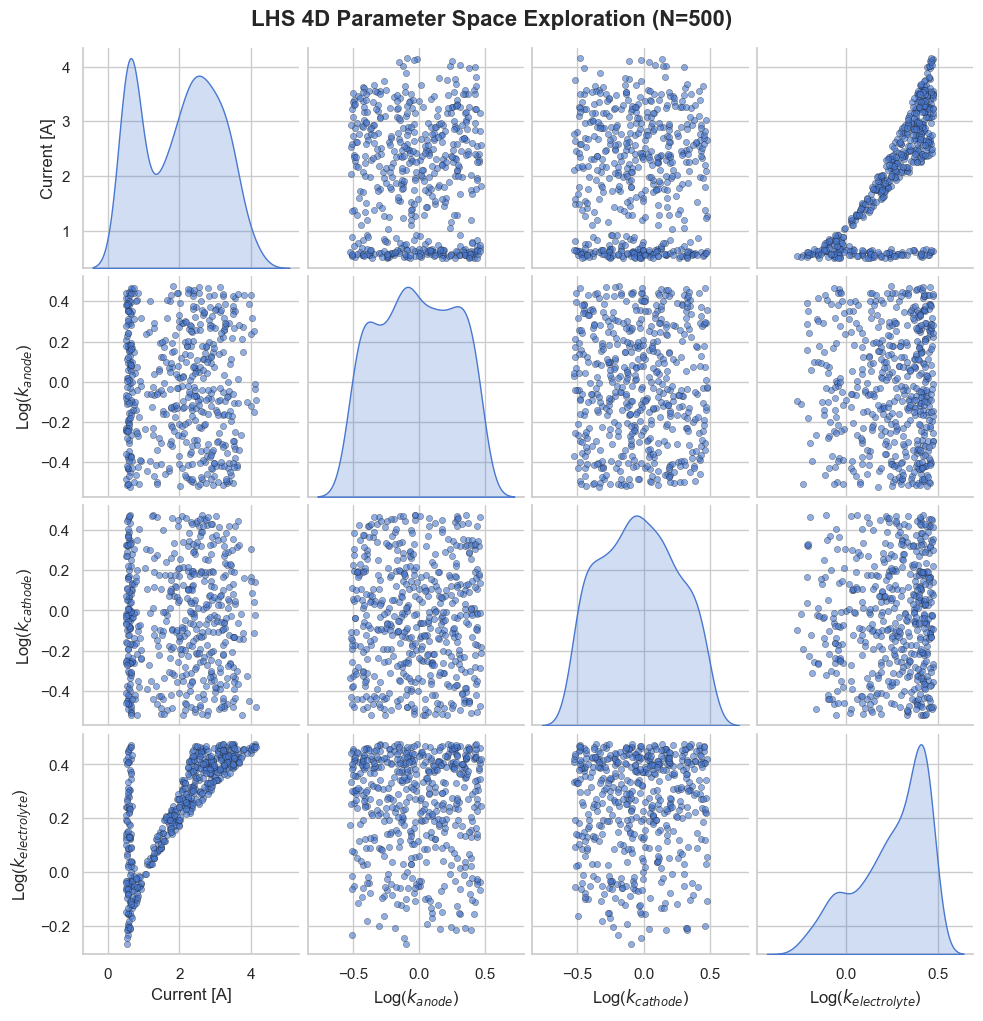

In [3]:
# PLOT 1: 4D PARAMETER SPACE (PAIRPLOT)
df_params = pd.DataFrame({  # apply log scale to the scale factors for better visualization
    'Current [A]': currents,
    'Log($k_{anode}$)': np.log10(k_anode),
    'Log($k_{cathode}$)': np.log10(k_cathode),
    'Log($k_{electrolyte}$)': np.log10(k_electrolyte),
})
pairplot = sns.pairplot(    # Generates a grid of scatter plots for each pair of parameters, with KDE on the diagonal
    df_params,
    diag_kind="kde",
    plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'k'}
)
pairplot.figure.suptitle(f"LHS 4D Parameter Space Exploration (N={num_samples})", y=1.02, fontsize=16, fontweight='bold')
# pairplot.figure.savefig('Fig1_Pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

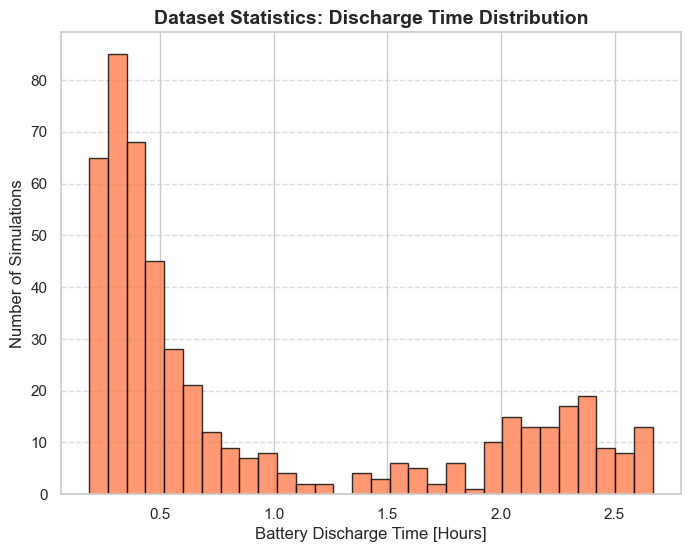

In [4]:
# PLOT 2: STATISTICAL ANALYSIS (DISCHARGE TIME HISTOGRAM)
fig2, ax2 = plt.subplots(figsize=(8, 6))
T_hours = T_durations / 3600.0  # Convert seconds to hours for readability
ax2.hist(T_hours, bins=30, color='coral', edgecolor='black', alpha=0.8)
ax2.set_title('Dataset Statistics: Discharge Time Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Battery Discharge Time [Hours]', fontsize=12)
ax2.set_ylabel('Number of Simulations', fontsize=12)
ax2.grid(True, axis='y', ls="--", alpha=0.7)
# fig2.savefig('Fig2_Histogram.png', dpi=300, bbox_inches='tight')
plt.show()

<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
C:\Users\angel\AppData\Local\Temp\ipykernel_3516\353441072.py:58: SyntaxWarning: invalid escape sequence '\m'
  ax_heat[i].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')


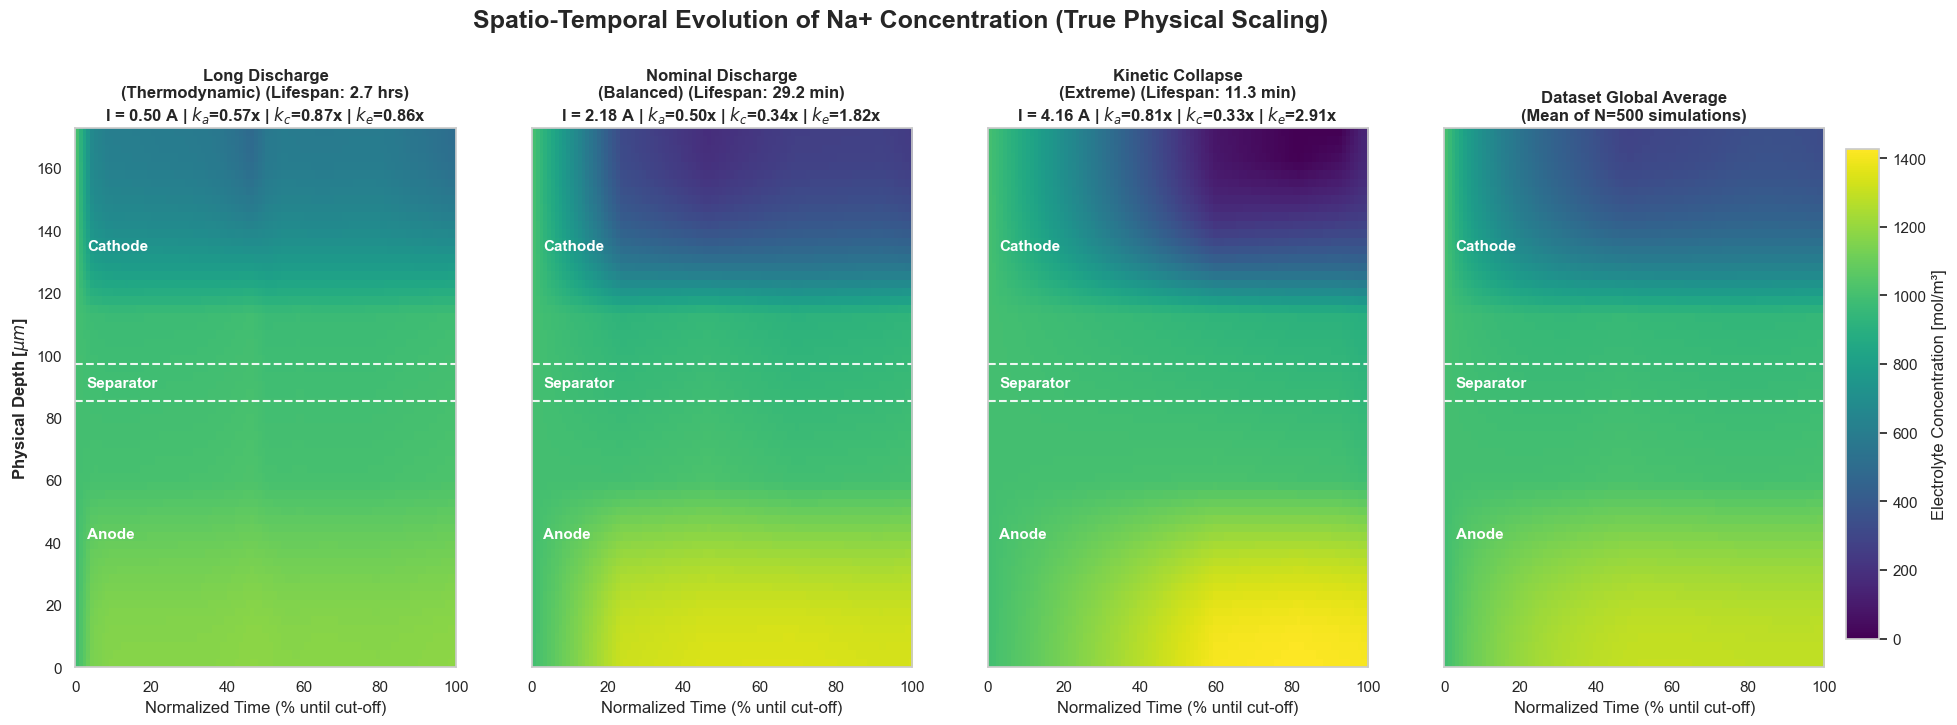

In [5]:
# PLOT 3: SPATIO-TEMPORAL HEATMAPS OF ELECTROLYTE CONCENTRATION
# Identify three representative scenarios based on their discharge time
idx_long = np.argmax(T_hours)
target_time = np.median(T_hours)    # Was hardcoded to 0.9 
idx_mid = np.argmin(np.abs(T_hours - target_time))
idx_short = np.argmin(T_hours)
indices_to_show = [idx_long, idx_mid, idx_short]
titles = ['Long Discharge\n(Thermodynamic)', 'Nominal Discharge\n(Balanced)', 'Kinetic Collapse\n(Extreme)']

# Calculate the Global Average Heatmap across the dataset
# Y shape is (N, Space, Time). Mean over axis 0 collapses N, resulting in (Space, Time)
Y_global_mean = np.mean(Y, axis=0)

fig3, ax_heat = plt.subplots(1, 4, figsize=(22, 7))

# Global vmin and vmax for consistent color scaling across the heatmaps
vmin = min(np.min(Y[indices_to_show]), np.min(Y_global_mean))
vmax = max(np.max(Y[indices_to_show]), np.max(Y_global_mean))

for i, idx in enumerate(indices_to_show):
    data = Y[idx] # Shape: (Space, Time)

    # Extract exact parameters for the title
    val_I = X[idx, 0]
    val_ka = X[idx, 1]
    val_kc = X[idx, 2]
    val_ke = X[idx, 3]
    time_h = T_hours[idx]

    if time_h < 0.017:  # under 1 minute
        duration_str = f"{time_h*3600:.0f} sec"
    elif time_h < 1:
        duration_str = f"{time_h*60:.1f} min"
    else:
        duration_str = f"{time_h:.1f} hrs"
    
    fullTitle = (
        f"{titles[i]} (Lifespan: {duration_str})\n"
        f"I = {val_I:.2f} A | $k_a$={val_ka:.2f}x | $k_c$={val_kc:.2f}x | $k_e$={val_ke:.2f}x"
    )
    
    # We use 'extent' to map the Y-axis to actual micrometers instead of just node indices
    im = ax_heat[i].imshow(data, aspect='auto', origin='lower', cmap='viridis',
                            extent=[0, 100, 0, L_total], vmin=vmin, vmax=vmax)

    ax_heat[i].set_title(fullTitle, fontweight='bold', fontsize=12)

    # Draw the boundaries between materials and add labels for clarity
    ax_heat[i].axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax_heat[i].axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
    ax_heat[i].text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
    ax_heat[i].grid(False)
    ax_heat[i].set_xlabel('Normalized Time (% until cut-off)', fontsize=12)

    if i == 0:
        ax_heat[i].set_ylabel('Physical Depth [$\mu m$]', fontsize=12, fontweight='bold')
    else:
        ax_heat[i].set_yticklabels([])

# 4th - Global Average Heatmap
im_mean = ax_heat[3].imshow(Y_global_mean, aspect='auto', origin='lower', cmap='viridis',
                            extent=[0, 100, 0, L_total], vmin=vmin, vmax=vmax)
ax_heat[3].set_title(f"Dataset Global Average\n(Mean of N={num_samples} simulations)", fontweight='bold', fontsize=12)
ax_heat[3].axhline(y=sep_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
ax_heat[3].axhline(y=cat_start, color='white', linestyle='--', linewidth=1.5, alpha=0.9)
ax_heat[3].text(3, L_n/2, 'Anode', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].text(3, L_n + L_s/2, 'Separator', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].text(3, L_n + L_s + L_p/2, 'Cathode', color='white', va='center', fontweight='bold', fontsize=11)
ax_heat[3].grid(False)
ax_heat[3].set_xlabel('Normalized Time (% until cut-off)', fontsize=12)
ax_heat[3].set_yticklabels([])

# Colorbar
fig3.subplots_adjust(right=0.92)
cbar_ax = fig3.add_axes([0.93, 0.15, 0.015, 0.7]) # [left, bottom, width, height]
cbar = fig3.colorbar(im, cax=cbar_ax)
cbar.set_label('Electrolyte Concentration [mol/m\u00b3]', fontsize=12)

plt.suptitle('Spatio-Temporal Evolution of Na+ Concentration (True Physical Scaling)',
             fontsize=18, fontweight='bold', y=1.05)

plt.show()
# fig3.savefig('Fig3_Heatmaps.png', dpi=300, bbox_inches='tight')